# 01 Used Car Price Prediction: Initial EDA and Cleaning #

**Project question:** Can we estimate a fair used-car listing price from vehicle characteristics such as make, model, year, mileage, fuel type, transmission, drivetrain, and location?

**Target variable:** `price`

**Notebook output:** `../data/processed.csv`

**Important rule:** I do not overwrite `raw.csv`. The raw dataset stays unchanged so the workflow remains reproducible.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

Loading the CSV, fixing d-type error

In [86]:
df = pd.read_csv('../data/raw.csv', 
        dtype={
            'fuel_type': 'string',
            'engine_block': 'string'
}, 
low_memory=False)

In [87]:
df.dtypes

id                  str
vin                 str
price           float64
miles           float64
stock_no            str
year            float64
make                str
model               str
trim                str
body_type           str
vehicle_type        str
drivetrain          str
transmission        str
fuel_type        string
engine_size     float64
engine_block     string
seller_name         str
street              str
city                str
state               str
zip                 str
dtype: object

Inspection, answering what Columns exists, which are useful/useless, or are there impossible values etc.

In [88]:
df.shape

(393603, 21)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 393603 entries, 0 to 393602
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            393603 non-null  str    
 1   vin           393603 non-null  str    
 2   price         358486 non-null  float64
 3   miles         366590 non-null  float64
 4   stock_no      365910 non-null  str    
 5   year          393586 non-null  float64
 6   make          393603 non-null  str    
 7   model         388809 non-null  str    
 8   trim          354824 non-null  str    
 9   body_type     359578 non-null  str    
 10  vehicle_type  355365 non-null  str    
 11  drivetrain    354608 non-null  str    
 12  transmission  357922 non-null  str    
 13  fuel_type     322790 non-null  string 
 14  engine_size   320950 non-null  float64
 15  engine_block  320439 non-null  string 
 16  seller_name   391371 non-null  str    
 17  street        385674 non-null  str    
 18  city          3

In [90]:
df.describe()

,price,miles,year,engine_size
count,3.584860e+05,3.665900e+05,393586.000000,320950.000000
mean,2.601902e+04,7.566339e+04,2016.414829,2.785073
std,2.064007e+04,5.775442e+04,3.345400,1.236639
min,0.000000e+00,0.000000e+00,1981.000000,0.600000
25%,1.490000e+04,3.491375e+04,2015.000000,2.000000
50%,2.190000e+04,6.232800e+04,2017.000000,2.400000
75%,3.199500e+04,1.032830e+05,2019.000000,3.500000
max,1.288888e+06,2.300033e+06,2022.000000,8.400000


In [91]:
df.isna().sum().sort_values(ascending=False)

engine_block    73164
engine_size     72653
fuel_type       70813
drivetrain      38995
trim            38779
vehicle_type    38238
transmission    35681
price           35117
body_type       34025
stock_no        27693
miles           27013
street           7929
state            7836
city             7774
zip              7769
model            4794
seller_name      2232
year               17
id                  0
vin                 0
make                0
dtype: int64

In [92]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

### Initial observations

Write this in your own notebook after looking at the outputs above.

Example wording:

- The dataset contains 393603 rows and 21 columns.
- The target column is `price`.
- Several columns have missing values, especially `engine_block`, `engine_size`, and `fuel_type`.
- The missing values are large, for one feature alone approximately 18% are missing values, we must impute values for accuracy
- From .describe() we notice that there are no impossible years, impossible mileage, or impossible engine sizes. 
- The first cleaning priorities are the null values, D-type errors in engine_block and fuel type, and impossible prices.

## Target Variable check: `price`

In [93]:
TARGET = 'price'
df[TARGET].describe()

count    3.584860e+05
mean     2.601902e+04
std      2.064007e+04
min      0.000000e+00
25%      1.490000e+04
50%      2.190000e+04
75%      3.199500e+04
max      1.288888e+06
Name: price, dtype: float64

In [94]:
df[TARGET].isna().sum()

np.int64(35117)

In [95]:
#Checking for negative or zero values in the target variable
df.loc[(df[TARGET] <= 0), [TARGET]].head(20)


,price
3042,0.0
75459,0.0
143974,0.0
143980,0.0
178476,0.0
178477,0.0
288311,0.0
306097,0.0
321642,0.0
330959,0.0


### There are 11 values with a value of 0.0

I will remove rows where `price` is missing or less than or equal to zero because these rows cannot be used to train a supervised price-prediction model. I will not automatically remove expensive vehicles only because they are expensive. High prices may represent real luxury or collectible vehicles, so I will inspect extreme values before deciding whether to cap or remove them.

## Check Categorical Columns
Standardize Text-columns before modelling
Need to check common col values to see that there are no `_  Honda ` or `Honda  ` treated differently from `Honda` else we strip.

In [96]:
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
text_cols

['id',
 'vin',
 'stock_no',
 'make',
 'model',
 'trim',
 'body_type',
 'vehicle_type',
 'drivetrain',
 'transmission',
 'fuel_type',
 'engine_block',
 'seller_name',
 'street',
 'city',
 'state',
 'zip']

In [ ]:
for col in text_cols[:15]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(15))

### Categorical cleaning decision

I will standardize text columns by converting values to lowercase and stripping extra spaces. Rare makes or models will be handled during feature engineering. My goal is to retain as much information as possible in the dataset.


# Cleaning the Data 

I want to keep the data cleaning as minimal as possible, I will use these following steps to perform my cleaning: 

1. Keep `raw.csv` unchanged - Work on a copy of the data 
2. Remove duplicates 
3. Remove unusable rows (0.0)
4. Remove impossible numerical values
5. Standardize Text columns 
6. Impute missing values
7. Save the dataset as `processed.csv` 

In [112]:
# 1. Keep raw csv.unchanged
df_cleaned = df.copy()

# 2. Remove duplicates 
df_cleaned = df_cleaned.drop_duplicates()

# 3. Remove rows with 0.0 target values

df_cleaned = df_cleaned[df_cleaned[TARGET]>0]

# 4. Remove rows with impossible values in numerical columns for good practice 

#Mileage, year, and engine size should be within reasonable limits for used cars (Keep NULLS for imputation later)
df_cleaned = df_cleaned[df_cleaned["year"].between(1980, 2026) | df_cleaned["year"].isna()]

df_cleaned = df_cleaned[df_cleaned["miles"].between(0, 500000) | df_cleaned["miles"].isna()]

df_cleaned = df_cleaned[df_cleaned["engine_size"].between(0.6,8.4) | df_cleaned["engine_size"].isna()]

# Create an indicator before replacing 0
df_cleaned["miles_was_zero"] = (df_cleaned["miles"] == 0).astype(int)

# Treat 0 miles as missing
df_cleaned.loc[df_cleaned["miles"] == 0, "miles"] = np.nan

 # 5. Standardize text columns by stripping whitespace and converting to lowercase

for col in text_cols:
    df_cleaned[col] = (
        df_cleaned[col]
        .astype('string')
        .str.lower()
        .str.strip()
    )

df_cleaned.to_csv("../data/cleaned.csv", index=False)


## Simple imputation

At this stage, I use simple imputation to keep rows with missing predictor values instead of deleting them. Numeric columns are filled with the median because the median is less sensitive to outliers than the mean. Categorical columns are filled with `"unknown"` so missing category information is preserved as its own category.

For the final model evaluation, imputation should be done inside a train/test pipeline to avoid data leakage. This version is mainly for creating a simple cleaned `processed.csv`.

In [99]:
# 6. Impute missing values in numeric columns with median and categorical columns with "unknown"
df_imputed = df_cleaned.copy()
print(f"Rows after cleaning and imputation: {len(df)}")

TARGET = "price"

# Separate numeric and categorical predictor columns
numeric_cols = df_imputed.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

categorical_cols = df_imputed.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


# Numeric imputation: median
numeric_imputer = SimpleImputer(strategy="median")

df_imputed[numeric_cols] = numeric_imputer.fit_transform(
    df_imputed[numeric_cols]
)

# Categorical imputation: unknown
# Convert pandas pd.NA to np.nan first so sklearn does not break
df_imputed[categorical_cols] = (
    df_imputed[categorical_cols]
    .astype("object")
    .replace({pd.NA: np.nan})
)

categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="unknown"
)

df_imputed[categorical_cols] = categorical_imputer.fit_transform(
    df_imputed[categorical_cols]
)   

# Convert categorical columns back to pandas string type
for col in categorical_cols:
    df_imputed[col] = (
        df_imputed[col]
        .astype("string")
        .str.lower()
        .str.strip()
    )

Rows after cleaning and imputation: 393603


In [100]:
#7. Save cleaned and imputed dataset for modeling
df_imputed.to_csv("../data/imputed.csv", index=False)

In [101]:

before_rows = len(df)
after_rows = len(df_imputed)

print(f"Rows before cleaning: {before_rows:,}")
print(f"Rows after cleaning:  {after_rows:,}")
print(f"Rows removed:         {before_rows - after_rows:,}")
print(f"Percent removed:      {(before_rows - after_rows) / before_rows * 100:.2f}%")

Rows before cleaning: 393,603
Rows after cleaning:  358,434
Rows removed:         35,169
Percent removed:      8.94%


### Re-check the cleaned Data
After cleaning I confirm that the cleaning steps did what I expected and did not damage the dataset

In [102]:
df_imputed.info()

<class 'pandas.DataFrame'>
Index: 358434 entries, 0 to 393602
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              358434 non-null  string 
 1   vin             358434 non-null  string 
 2   price           358434 non-null  float64
 3   miles           358434 non-null  float64
 4   stock_no        358434 non-null  string 
 5   year            358434 non-null  float64
 6   make            358434 non-null  string 
 7   model           358434 non-null  string 
 8   trim            358434 non-null  string 
 9   body_type       358434 non-null  string 
 10  vehicle_type    358434 non-null  string 
 11  drivetrain      358434 non-null  string 
 12  transmission    358434 non-null  string 
 13  fuel_type       358434 non-null  string 
 14  engine_size     358434 non-null  float64
 15  engine_block    358434 non-null  string 
 16  seller_name     358434 non-null  string 
 17  street          358434 non

In [103]:
df_imputed.shape

(358434, 22)

In [104]:
df_imputed.isna().sum()


id                0
vin               0
price             0
miles             0
stock_no          0
year              0
make              0
model             0
trim              0
body_type         0
vehicle_type      0
drivetrain        0
transmission      0
fuel_type         0
engine_size       0
engine_block      0
seller_name       0
street            0
city              0
state             0
zip               0
miles_was_zero    0
dtype: int64

## 9. Basic EDA after cleaning

Now that obvious invalid rows are removed, I can look at the main relationships. This is still exploratory.

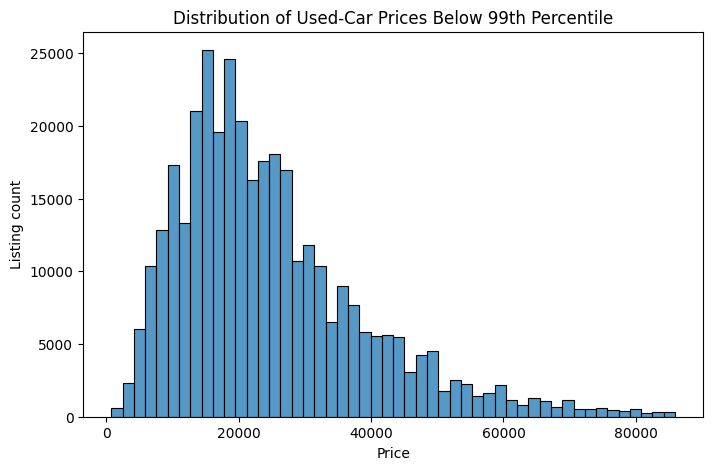

In [105]:
upper_price = df_imputed["price"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    df_imputed[df_imputed["price"] <= upper_price]["price"], # Removing upper 1% of prices to focus on the main distribution
    bins=50
)
plt.title("Distribution of Used-Car Prices Below 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Listing count")
plt.show()

In [ ]:
miles_upper = df_imputed["miles"].quantile(0.99)
plt.figure(figsize=(8,5))
sns.histplot(df_imputed.loc[df_imputed["miles"] <= miles_upper, "miles"], bins=20)
plt.title("Distribution of Used-Car Mileage")
plt.xlabel("Mileage")
plt.ylabel("Listing count")
plt.show()

In [ ]:
year_lower = df_imputed["year"].quantile(0.01)
plt.figure(figsize=(8,5))
sns.histplot(df_imputed.loc[df_imputed["year"] >= year_lower,"year"], bins = 17)
plt.title("Distribution of Years of Used Cars")
plt.xlabel("Years")
plt.ylabel("Listing count")
plt.show()

In [ ]:
year_lower = df_imputed["year"].quantile(0.01)
plt.figure(figsize=(8,5))
sns.histplot(df_imputed["engine_size"], bins = 30)
plt.title("Distribution of Used-Car Engine Size in Liters")
plt.xlabel("Size in Liters")
plt.ylabel("Listing count")
plt.show()

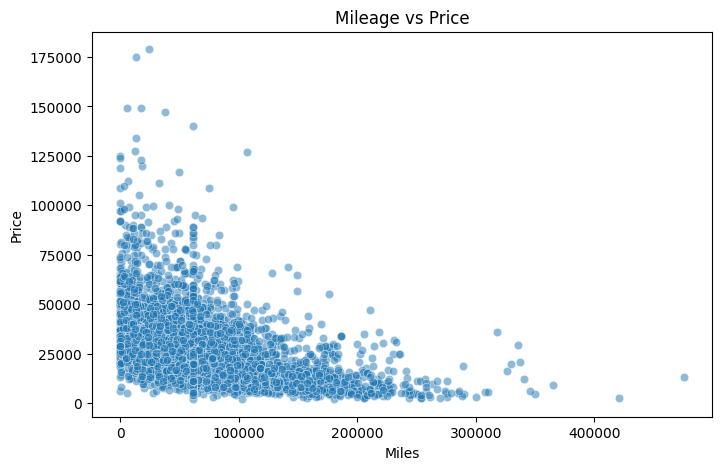

In [109]:

plt.figure(figsize=(8,5))
sns.scatterplot(data= df_imputed.sample(min(len(df_imputed), 5000),random_state = 67), x = "miles", y = TARGET, alpha= 0.5)
plt.title("Mileage vs Price")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.show()

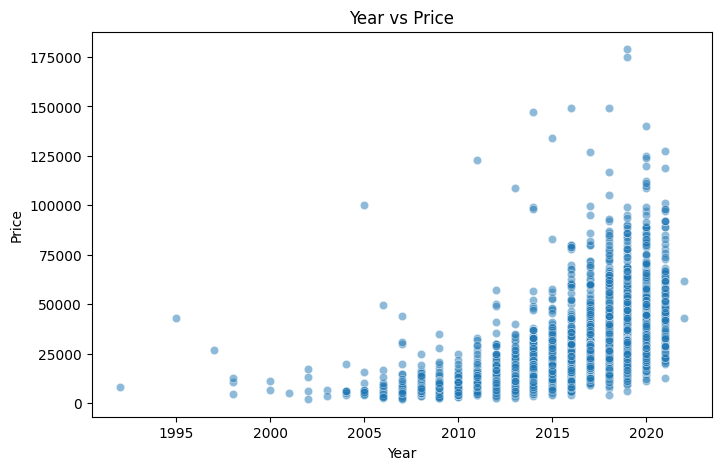

In [110]:
plt.figure(figsize=(8,5))
sns.scatterplot(data= df_imputed.sample(min(len(df_imputed), 5000),random_state = 67), x = "year", y = TARGET, alpha= 0.5)
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

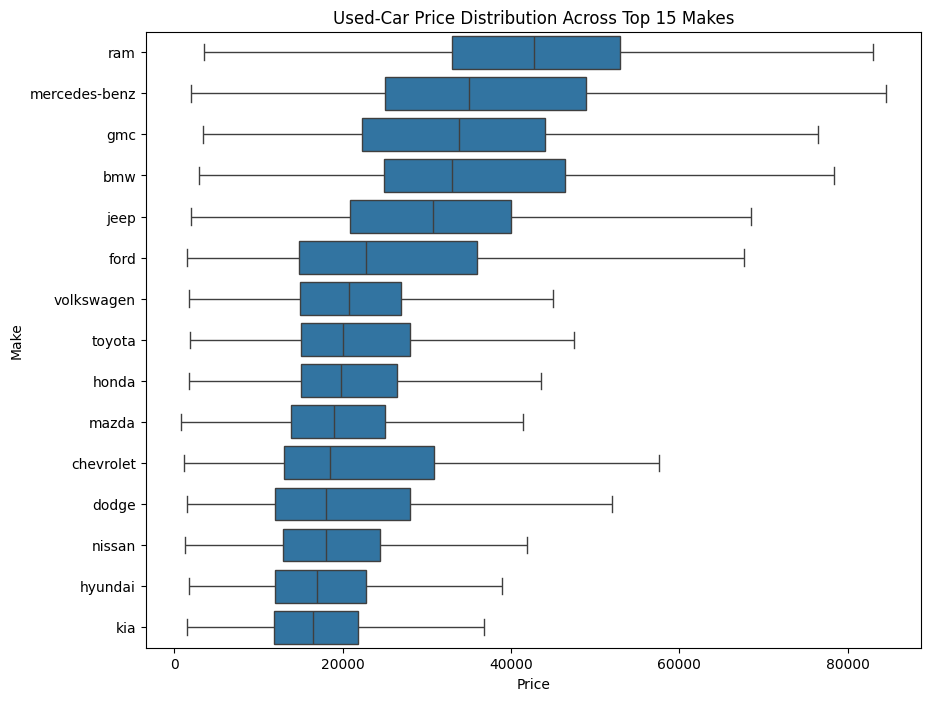

In [111]:
top_makes = df_imputed["make"].value_counts().head(15).index
plot_df = df_imputed[df_imputed["make"].isin(top_makes)].copy()

make_order = (
    plot_df.groupby("make")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 8))

sns.boxplot(
    data=plot_df,
    y="make",
    x="price",
    order=make_order,
    showfliers=False
)

plt.title("Used-Car Price Distribution Across Top 15 Makes")
plt.xlabel("Price")
plt.ylabel("Make")
plt.show()

## Notebook conclusion

This notebook completed the first stage of the used-car price prediction project. I loaded the raw dataset, fixed dtype loading issues, inspected missing values and duplicates, removed unusable target rows, handled impossible numerical values, treated suspicious zero-mileage listings as missing, applied simple imputation, and created initial EDA visualizations.

The main patterns are that used-car prices are right-skewed, higher mileage is generally associated with lower price, newer vehicles tend to be more expensive, and price distributions differ strongly by make. The next notebook will focus on feature engineering, including vehicle age, miles per year, region, and model/trim combinations.

For final modeling, imputation and encoding should be moved into a scikit-learn pipeline to avoid data leakage.